In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import precision_score, recall_score

In [3]:
from Meta_learning import MetaLearner
import Meta_loss_functions as mlf

In [4]:
class Generator(nn.Module):
    def __init__(self, num_classes, n_per_class):
        super().__init__()
        self.num_classes = num_classes
        self.n_per_class = n_per_class
        self.total = num_classes * n_per_class
        
        self.data = nn.Parameter(
            torch.rand(self.total, 1, 4, 4)
        )
    
    def forward(self, z=None, y=None):
        return self.data
    
    def visualize(self, x, y, n_visualize=10):
        cols = min(n_visualize, self.n_per_class)
        rows = self.num_classes
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
        
        if rows == 1:
            axes = np.expand_dims(axes, axis=0)
        if cols == 1:
            axes = np.expand_dims(axes, axis=1)
        
        for i in range(rows):
            class_indices = (y == i).nonzero(as_tuple=True)[0]
            
            for j in range(cols):
                if j < len(class_indices):
                    idx = class_indices[j]
                    ax = axes[i, j]
                    
                    img = x[idx, 0].detach().cpu().numpy()
                    
                    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation='nearest')
                    ax.set_xticks([])
                    ax.set_yticks([])
                    
                    if j == 0:
                        ax.set_ylabel(f"Class {i}", fontsize=10)
                
                for spine in axes[i, j].spines.values():
                    spine.set_visible(True)
                    spine.set_color('black')
                    spine.set_linewidth(1)
        plt.tight_layout()
        plt.show()

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1, 
            out_channels=4, 
            kernel_size=2, 
            stride=2
        )
        self.fc = nn.Linear(4 * 1 * 1, num_classes)
    
    def forward(self, x):
        x = self.conv(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

step: 1487, meta_loss: -0.9487, accuracy: 100.00%


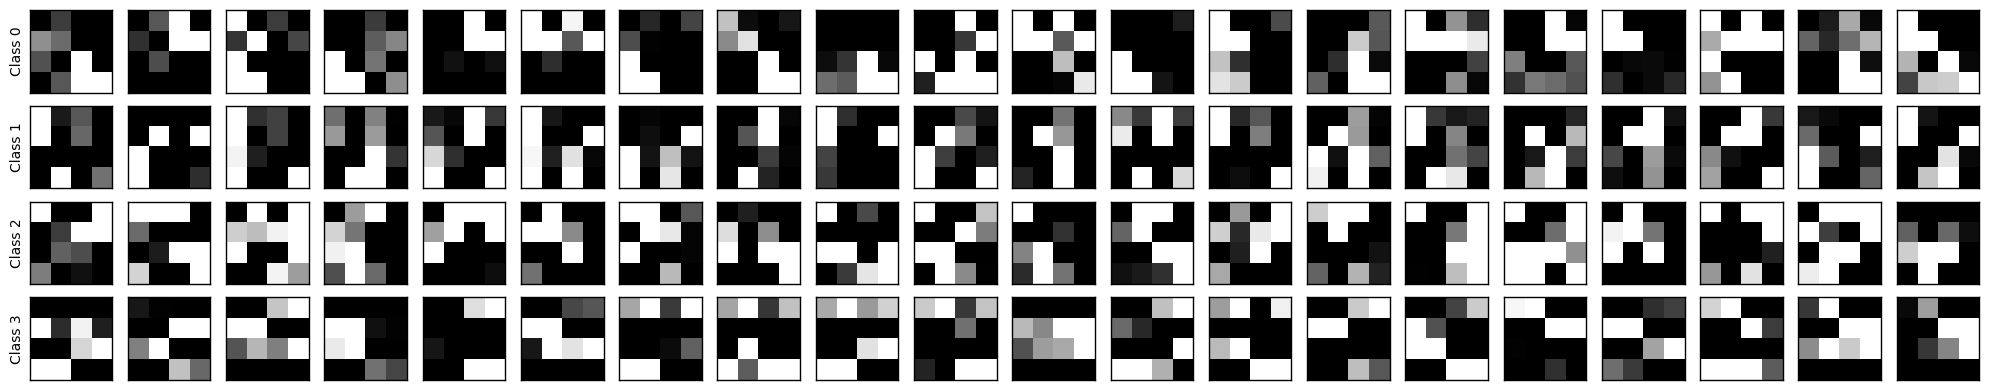

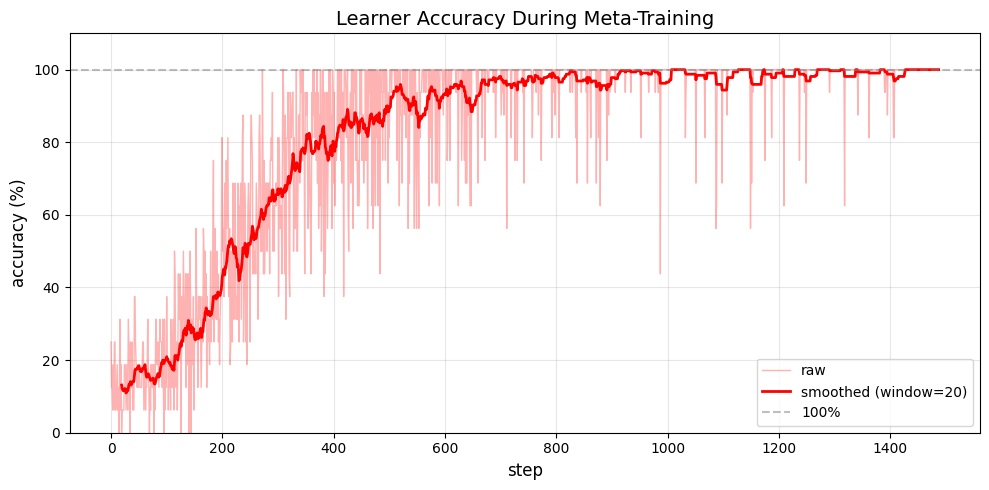

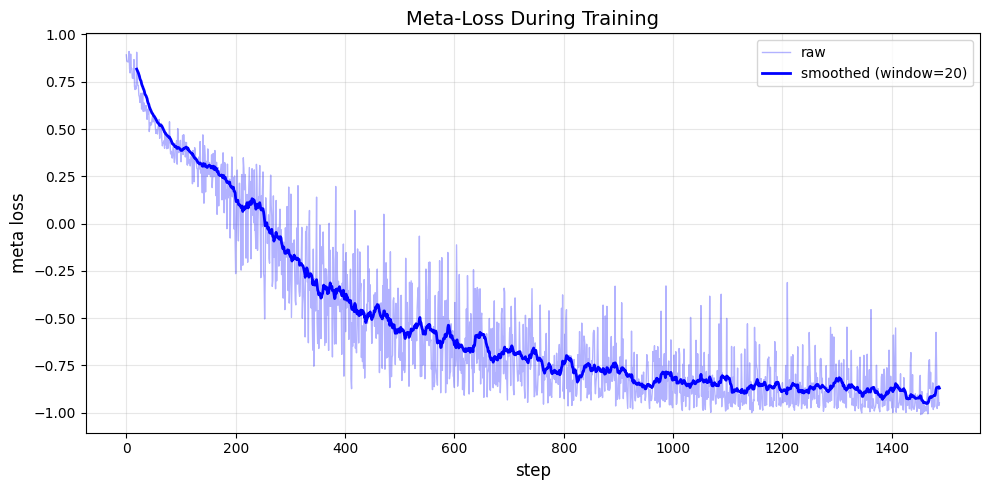

In [15]:
generator_ce_div = Generator(num_classes=4, n_per_class=20)

meta = MetaLearner(
    generator=generator_ce_div,
    learner_class=CNN,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    regularization_fn=mlf.regularizer_class_diversity,
    reg_parameter=1.5,
    num_classes=4,
    n_per_class=20,
    meta_lr=0.01,
    inner_lr=0.5, 
    inner_steps=10,
    stop_after_consecutive_100=80
)

meta.train(steps=5000, visualize_every=0)
meta.plot_accuracy(20)
meta.plot_meta_loss(20)
acc_ce_div = meta.get_accuracy_history()

In [8]:
def shuffle_2x2_blocks(x, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    
    batch_size = x.shape[0]
    x_shuffled = x.clone()

    blocks = [(0, 0), (0, 2), (2, 0), (2, 2)]
    
    for i in range(batch_size):
        block_values = []
        for h, w in blocks:
            block = x[i, :, h:h+2, w:w+2].clone()
            block_values.append(block)

        perm = torch.randperm(4)
        shuffled_blocks = [block_values[p] for p in perm]

        for idx, (h, w) in enumerate(blocks):
            x_shuffled[i, :, h:h+2, w:w+2] = shuffled_blocks[idx]
    
    return x_shuffled

def create_shuffled_dataset(generator, num_classes, n_per_class, seed=None):
    y = torch.arange(num_classes).repeat_interleave(n_per_class)
    x = generator.forward()
    x_shuffled = shuffle_2x2_blocks(x, seed=seed)
    return x_shuffled, y

In [16]:
num_classes = 4
n_per_class = 20
x = generator_ce_div.forward().detach()
y = torch.arange(num_classes).repeat_interleave(n_per_class)

Data type       Accuracy (%)        
--------------------------------------------------
Original        99.69 ± 2.56                
Seed 42         99.65 ± 2.53
Seed 123        99.65 ± 2.53
Seed 456        99.65 ± 2.53
Seed 789        99.65 ± 2.53

Seed 42:


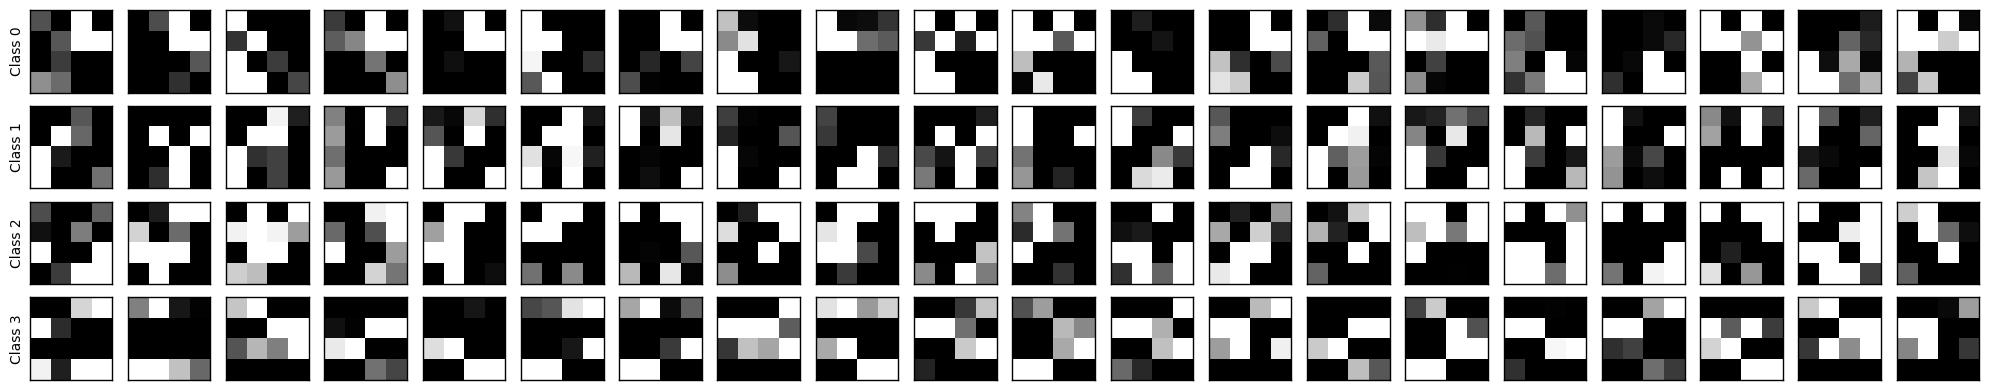


Seed 123:


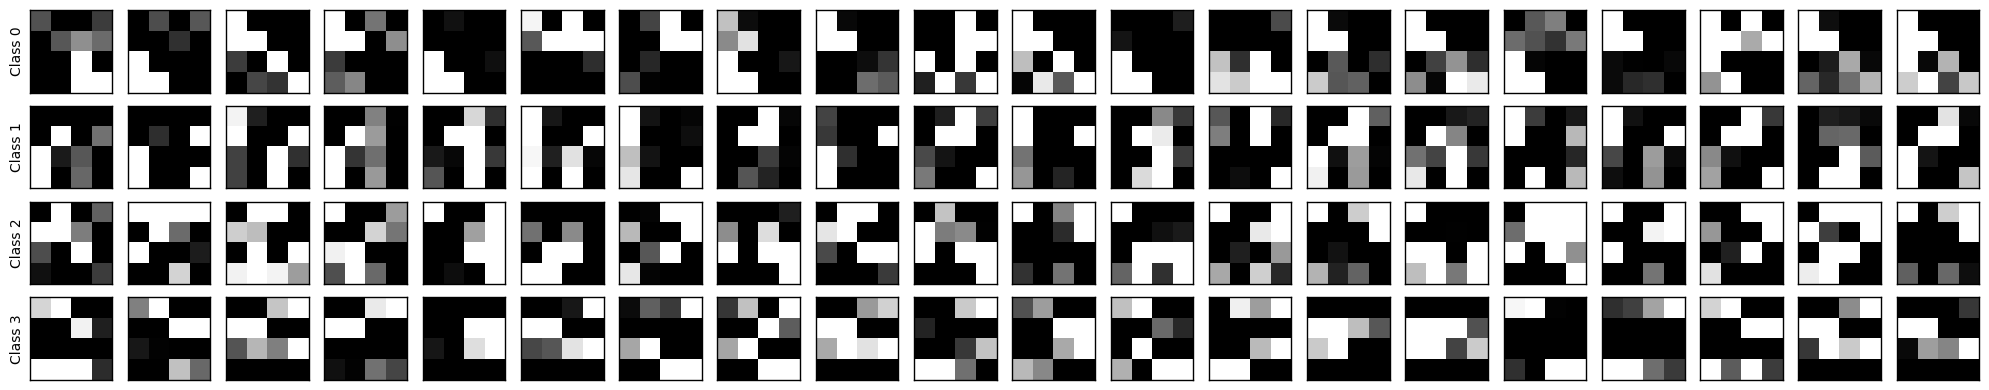


Seed 456:


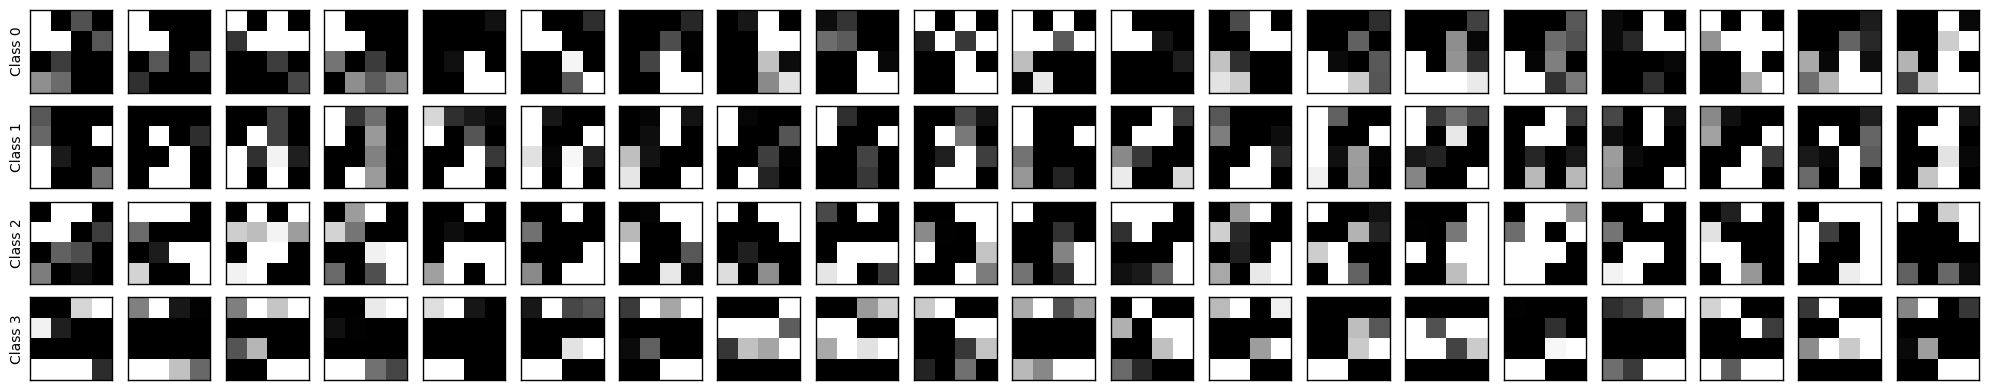


Seed 789:


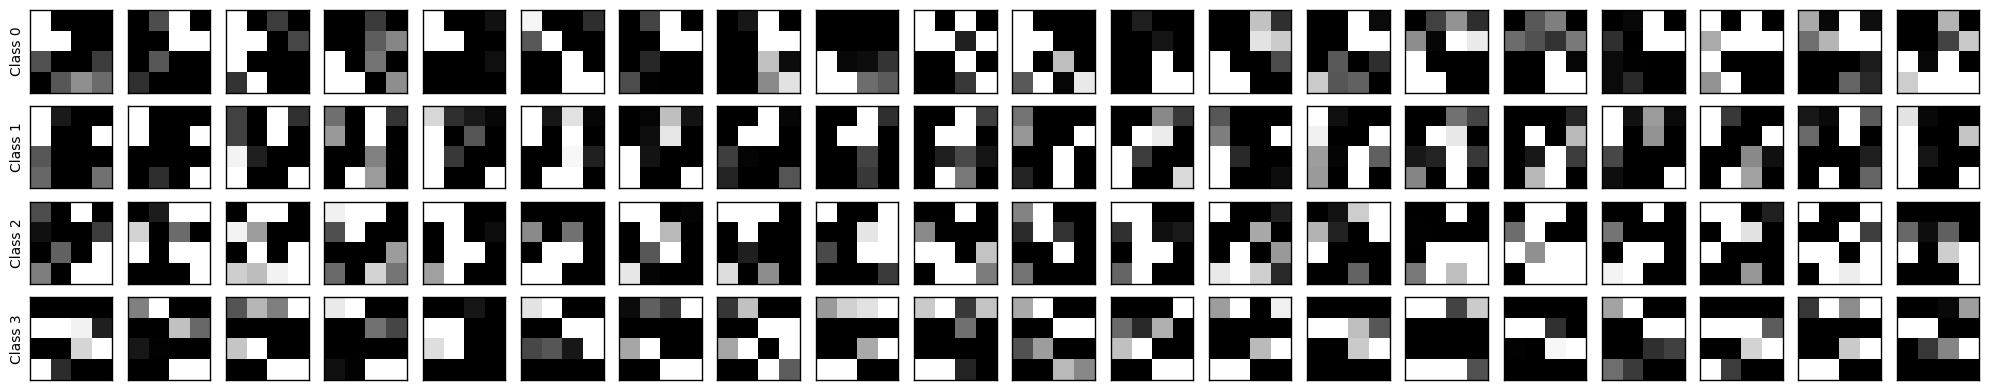

In [17]:
num_cnns = 100
seeds = [42, 123, 456, 789]

results = {
    'original': [],
    'shuffled': {seed: [] for seed in seeds}
}

shuffled_examples = {}

for cnn_idx in range(num_cnns):    
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    cnn = CNN(num_classes=num_classes)
    optimizer = torch.optim.SGD(cnn.parameters(), lr=0.5)
    
    for epoch in range(10):
        optimizer.zero_grad()
        logits = cnn.forward(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    cnn.eval()
    with torch.no_grad():
        logits = cnn.forward(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    for seed in seeds:
        x_shuffled, y_shuffled = create_shuffled_dataset(
            generator_ce_div, num_classes, n_per_class, seed=seed
        )
        x_shuffled = x_shuffled.detach()
        
        if cnn_idx == 0:
            shuffled_examples[seed] = (x_shuffled, y_shuffled)
        
        with torch.no_grad():
            logits = cnn.forward(x_shuffled)
            preds = logits.argmax(dim=1)
            acc_shuffled = (preds == y_shuffled).float().mean().item() * 100
        results['shuffled'][seed].append(acc_shuffled)
    cnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
for seed in seeds:
    mean_shuffled = np.mean(results['shuffled'][seed])
    std_shuffled = np.std(results['shuffled'][seed])
    print(f"Seed {seed:<10} {mean_shuffled:.2f} ± {std_shuffled:.2f}")

for seed in seeds:
    if seed in shuffled_examples:
        x_shuffled, y_shuffled = shuffled_examples[seed]
        print(f"\nSeed {seed}:")
        generator_ce_div.visualize(x_shuffled, y_shuffled, n_per_class)

In [18]:
x_shuffled, y_shuffled = create_shuffled_dataset(generator_ce_div, num_classes, n_per_class, seed=42)
x_shuffled = x_shuffled.detach()

In [19]:
num_trials = 100

accuracies_on_shuffled = []
accuracies_on_original = []

for trial in range(num_trials):
    total = x_shuffled.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    x_shuffled_train = x_shuffled[train_idx]
    y_shuffled_train = y_shuffled[train_idx]
    x_shuffled_test = x_shuffled[test_idx]
    y_shuffled_test = y_shuffled[test_idx]

    cnn_shuffled = CNN(num_classes=4)
    optimizer = torch.optim.SGD(cnn_shuffled.parameters(), lr=0.5)
    
    for epoch in range(10):
        optimizer.zero_grad()
        logits = cnn_shuffled.forward(x_shuffled_train)
        loss = F.cross_entropy(logits, y_shuffled_train)
        loss.backward()
        optimizer.step()

    cnn_shuffled.eval()
    with torch.no_grad():
        logits = cnn_shuffled.forward(x_shuffled_test)
        preds = logits.argmax(dim=1)
        acc_shuffled = (preds == y_shuffled_test).float().mean().item() * 100
    accuracies_on_shuffled.append(acc_shuffled)
    
    with torch.no_grad():
        logits = cnn_shuffled.forward(x)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y).float().mean().item() * 100
    accuracies_on_original.append(acc_original)

print(f"Shuffled: {np.mean(accuracies_on_shuffled):.2f}% ± {np.std(accuracies_on_shuffled):.2f}%")
print(f"Original: {np.mean(accuracies_on_original):.2f}% ± {np.std(accuracies_on_original):.2f}%")

Shuffled: 99.00% ± 5.57%
Original: 99.24% ± 3.85%


In [20]:
class MLP(nn.Module):
    def __init__(self, num_classes, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(16, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 16)
        self.fc3 = nn.Linear(16, num_classes)
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [21]:
num_mlps = 100

results = {
    'original': [],
    'shuffled': {seed: [] for seed in seeds}
}

for mlp_ind in range(num_mlps):
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    mlp = MLP(num_classes=num_classes)
    optimizer = torch.optim.SGD(mlp.parameters(), lr=0.5)
    
    for epoch in range(10):
        optimizer.zero_grad()
        logits = mlp.forward(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    mlp.eval()
    with torch.no_grad():
        logits = mlp.forward(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    for seed in seeds:
        x_shuffled, y_shuffled = create_shuffled_dataset(
            generator_ce_div, num_classes, n_per_class, seed=seed
        )
        x_shuffled = x_shuffled.detach()
        
        with torch.no_grad():
            logits = mlp.forward(x_shuffled)
            preds = logits.argmax(dim=1)
            acc_shuffled = (preds == y_shuffled).float().mean().item() * 100
        results['shuffled'][seed].append(acc_shuffled)
    mlp.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
for seed in seeds:
    mean_shuffled = np.mean(results['shuffled'][seed])
    std_shuffled = np.std(results['shuffled'][seed])
    print(f"Seed {seed:<10} {mean_shuffled:.2f} ± {std_shuffled:.2f}")

Data type       Accuracy (%)        
--------------------------------------------------
Original        55.31 ± 15.52                
Seed 42         76.21 ± 8.55
Seed 123        76.88 ± 9.16
Seed 456        77.49 ± 8.53
Seed 789        76.35 ± 7.67


In [22]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)
    
    def train_model(self, x_train, y_train, epochs=30, lr=0.05, verbose=False):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = F.cross_entropy(self.forward(x_train), y_train)
            loss.backward()
            optimizer.step()
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            preds = self.forward(x).argmax(dim=1)
        self.train()
        return preds
    
    def accuracy(self, x_test, y_test):
        preds = self.predict(x_test)
        return (preds == y_test).float().mean().item() * 100

In [23]:
def train_and_save_block_classifiers(x, y, num_classes):
    blocks = [(0, 0, 2, 2), (0, 2, 2, 4), (2, 0, 4, 2), (2, 2, 4, 4)]
    block_names = ['top-left', 'top-right', 'bottom-left', 'bottom-right']
    
    block_classifiers = {}
    
    for block_idx, (h1, w1, h2, w2) in enumerate(blocks):
        x_block = x[:, :, h1:h2, w1:w2]
        x_block_flat = x_block.reshape(x_block.size(0), -1)
        
        clf = SimpleClassifier(input_dim=4, hidden_dim=8, num_classes=num_classes)
        clf.train_model(x_block_flat, y, epochs=30, lr=0.05, verbose=True)
        
        block_classifiers[block_names[block_idx]] = clf

        y_pred = clf.predict(x_block_flat)

        precision = precision_score(y, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y, y_pred, average='weighted', zero_division=0)
         
        print(f"\nBlock {block_names[block_idx]}:")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
    
    return block_classifiers

def evaluate_blocks_on_data(x, y, num_classes, block_classifiers):
    blocks = [(0, 0, 2, 2), (0, 2, 2, 4), (2, 0, 4, 2), (2, 2, 4, 4)]
    block_names = ['top-left', 'top-right', 'bottom-left', 'bottom-right']
    
    results = {}
    
    for block_idx, (h1, w1, h2, w2) in enumerate(blocks):
        x_block = x[:, :, h1:h2, w1:w2]
        x_block_flat = x_block.reshape(x_block.size(0), -1)
        
        clf = block_classifiers[block_names[block_idx]]
        y_pred = clf.predict(x_block_flat)

        precision = precision_score(y, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y, y_pred, average='weighted', zero_division=0)
        
        results[block_names[block_idx]] = {
            'precision': precision,
            'recall': recall,
        }
        
        print(f"\nBlock {block_names[block_idx]}:")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
    
    return results

In [24]:
block_classifiers = train_and_save_block_classifiers(x, y, num_classes=4)


Block top-left:
  Precision: 0.9257
  Recall:    0.9125

Block top-right:
  Precision: 0.9385
  Recall:    0.9375

Block bottom-left:
  Precision: 0.9217
  Recall:    0.9125

Block bottom-right:
  Precision: 0.9160
  Recall:    0.9125


In [25]:
x_shuffled, y_shuffled = create_shuffled_dataset(generator_ce_div, num_classes, n_per_class, seed=42)
x_shuffled = x_shuffled.detach()

results_original = evaluate_blocks_on_data(x_shuffled, y_shuffled, 4, block_classifiers)


Block top-left:
  Precision: 0.9583
  Recall:    0.9500

Block top-right:
  Precision: 0.8691
  Recall:    0.8625

Block bottom-left:
  Precision: 0.9375
  Recall:    0.9250

Block bottom-right:
  Precision: 0.9432
  Recall:    0.9375
